# Part 2a

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.ticker as ticker
import numpy as np
import re
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

In [181]:
paths = []
folder_2a = Path("results/part2a")
measurement_folders_2a = [f.name for f in folder_2a.iterdir() if f.is_dir()]

In [182]:
real_pattern = re.compile(r"^real\s+(\d+)m([\d.]+)s")

def extract_real_time(log_file):
    for line in log_file:
        match = real_pattern.match(line.strip())
        if match:
            minutes = int(match.group(1))
            seconds = float(match.group(2))
            return minutes * 60 + seconds

In [183]:
def fill_dataframe(path, run):
    with open(path, "r", encoding="utf-8") as f:
        real_time = extract_real_time(f)
        measurement_combination = Path(path).parent.name
        y = {"measurement": measurement_combination, "time": real_time, "run": run}
    return y

In [184]:
# create dataframe with all measurements
part2a_measurement_list = []

for subdir in measurement_folders_2a:
    files_pattern = "results/part2a/" + subdir + "/*.log"
    # print(files_pattern)
    files = glob.glob(files_pattern)
    # print(files)
    run = 0
    for path in files:
        run += 1
        part2a_measurement_list.append(fill_dataframe(path, run))

part2a_dataframe = pd.DataFrame(part2a_measurement_list)
part2a_dataframe

,measurement,time,run
0,vips_l1i,189.006,1
1,vips_l1i,204.675,2
2,canneal_l1i,10.810,1
3,canneal_l1i,13.236,2
4,freqmine_membw,12.448,1
...,...,...,...
94,barnes_cpu,213.047,2
95,barnes_llc,355.959,1
96,barnes_llc,240.924,2
97,blackscholes_cpu,1.106,1


In [185]:
# generate the mean of the measurements

part2a_dataframe_avg = (
    part2a_dataframe.groupby("measurement", as_index=False)
    .agg(
        mean_runtime=("time", "mean"),
    )
)

part2a_dataframe_avg[['parsec_benchmark', 'interference']] = part2a_dataframe_avg['measurement'].str.split('_', expand=True)

part2a_dataframe_avg

,measurement,mean_runtime,parsec_benchmark,interference
0,barnes_cpu,220.306000,barnes,cpu
1,barnes_l1d,233.625000,barnes,l1d
2,barnes_l1i,263.893500,barnes,l1i
3,barnes_l2,240.300500,barnes,l2
4,barnes_llc,298.441500,barnes,llc
5,barnes_membw,233.434500,barnes,membw
6,barnes_none,148.522333,barnes,none
7,blackscholes_cpu,1.166500,blackscholes,cpu
8,blackscholes_l1d,1.211500,blackscholes,l1d
9,blackscholes_l1i,1.679500,blackscholes,l1i


In [186]:
baseline = part2a_dataframe_avg.loc[part2a_dataframe_avg['interference'] == 'none', ['parsec_benchmark', 'mean_runtime']]
baseline = baseline.rename(columns={'mean_runtime': 'baseline'})

part2a_dataframe_avg = part2a_dataframe_avg.merge(baseline, on='parsec_benchmark')

part2a_dataframe_avg['normalized_runtime'] = part2a_dataframe_avg['mean_runtime'] / part2a_dataframe_avg['baseline']

part2a_dataframe_avg

,measurement,mean_runtime,parsec_benchmark,interference,baseline,normalized_runtime
0,barnes_cpu,220.306000,barnes,cpu,148.522333,1.483319
1,barnes_l1d,233.625000,barnes,l1d,148.522333,1.572996
2,barnes_l1i,263.893500,barnes,l1i,148.522333,1.776793
3,barnes_l2,240.300500,barnes,l2,148.522333,1.617942
4,barnes_llc,298.441500,barnes,llc,148.522333,2.009405
5,barnes_membw,233.434500,barnes,membw,148.522333,1.571713
6,barnes_none,148.522333,barnes,none,148.522333,1.000000
7,blackscholes_cpu,1.166500,blackscholes,cpu,0.944500,1.235045
8,blackscholes_l1d,1.211500,blackscholes,l1d,0.944500,1.282689
9,blackscholes_l1i,1.679500,blackscholes,l1i,0.944500,1.778190


In [187]:
table = part2a_dataframe_avg.pivot_table(
    index='parsec_benchmark',
    columns='interference',
    values='normalized_runtime'
)

table

interference,cpu,l1d,l1i,l2,llc,membw,none
parsec_benchmark,,,,,,,
barnes,1.483319,1.572996,1.776793,1.617942,2.009405,1.571713,1.0
blackscholes,1.235045,1.282689,1.778190,1.452620,1.391212,1.296983,1.0
canneal,1.124229,1.290818,1.246747,1.293462,1.796962,1.333904,1.0
freqmine,1.925005,1.321517,1.960314,1.323635,1.744086,1.607161,1.0
radix,0.956131,1.087802,0.985327,1.098419,1.406415,1.023650,1.0
streamcluster,1.581897,1.388922,1.493549,1.391039,1.836307,1.391896,1.0
vips,1.635678,1.729200,1.712699,1.690294,1.898886,1.758275,1.0


# Part 2b

In [188]:
paths = []
folder_2b = Path("results/part2b")
measurement_folders_2b = [f.name for f in folder_2b.iterdir() if f.is_dir()]

In [189]:
# create dataframe with all measurements
part2b_measurement_list = []

for subdir in measurement_folders_2b:
    files_pattern = "results/part2b/" + subdir + "/*.log"
    # print(files_pattern)
    files = glob.glob(files_pattern)
    # print(files)
    run = 0
    for path in files:
        run += 1
        part2b_measurement_list.append(fill_dataframe(path, run))

part2b_dataframe = pd.DataFrame(part2b_measurement_list)
part2b_dataframe

,measurement,time,run
0,freqmine_8t,66.039,1
1,freqmine_8t,67.447,2
2,radix_8t,5.357,1
3,radix_8t,5.437,2
4,radix_2t,17.210,1
5,radix_2t,17.122,2
6,freqmine_2t,168.901,1
7,freqmine_2t,169.821,2
8,freqmine_1t,331.876,1
9,freqmine_1t,336.769,2


In [190]:
# generate the mean of the measurements

part2b_dataframe_avg = (
    part2b_dataframe.groupby("measurement", as_index=False)
    .agg(
        mean_runtime=("time", "mean"),
        std_runtime=("time", "std")
    )
)

part2b_dataframe_avg[['parsec_benchmark', 'threads']] = part2b_dataframe_avg['measurement'].str.split('_', expand=True)

part2b_dataframe_avg["threads"] = part2b_dataframe_avg["threads"].str.rstrip("t").astype(int)

part2b_dataframe_avg

,measurement,mean_runtime,std_runtime,parsec_benchmark,threads
0,barnes_1t,108.9845,2.105057,barnes,1
1,barnes_2t,55.6195,1.351281,barnes,2
2,barnes_4t,28.8775,0.721956,barnes,4
3,barnes_8t,22.5440,0.554372,barnes,8
4,blackscholes_1t,64.5260,0.579828,blackscholes,1
5,blackscholes_2t,37.9610,0.277186,blackscholes,2
6,blackscholes_4t,24.9340,0.615183,blackscholes,4
7,blackscholes_8t,21.1730,0.096167,blackscholes,8
8,canneal_1t,233.1490,8.611146,canneal,1
9,canneal_2t,147.5165,6.187891,canneal,2


In [191]:
baseline = part2b_dataframe_avg.loc[part2b_dataframe_avg['threads'] == 1, ['parsec_benchmark', 'mean_runtime', 'std_runtime']]
baseline = baseline.rename(columns={'mean_runtime': 'baseline', 'std_runtime': 'baseline_std'})

part2b_dataframe_avg = part2b_dataframe_avg.merge(baseline, on='parsec_benchmark')

part2b_dataframe_avg['speedup'] = part2b_dataframe_avg['baseline'] / part2b_dataframe_avg['mean_runtime']

part2b_dataframe_avg['std_speedup'] = (
    part2b_dataframe_avg['speedup'] *
    np.sqrt(
        (part2b_dataframe_avg['baseline_std'] /
         part2b_dataframe_avg['baseline'])**2
        +
        (part2b_dataframe_avg['std_runtime'] /
         part2b_dataframe_avg['mean_runtime'])**2
    )
)

part2b_dataframe_avg

,measurement,mean_runtime,std_runtime,parsec_benchmark,threads,baseline,baseline_std,speedup,std_speedup
0,barnes_1t,108.9845,2.105057,barnes,1,108.9845,2.105057,1.000000,0.027316
1,barnes_2t,55.6195,1.351281,barnes,2,108.9845,2.105057,1.959466,0.060817
2,barnes_4t,28.8775,0.721956,barnes,4,108.9845,2.105057,3.774028,0.119232
3,barnes_8t,22.5440,0.554372,barnes,8,108.9845,2.105057,4.834302,0.151166
4,blackscholes_1t,64.5260,0.579828,blackscholes,1,64.5260,0.579828,1.000000,0.012708
5,blackscholes_2t,37.9610,0.277186,blackscholes,2,64.5260,0.579828,1.699797,0.019681
6,blackscholes_4t,24.9340,0.615183,blackscholes,4,64.5260,0.579828,2.587872,0.067952
7,blackscholes_8t,21.1730,0.096167,blackscholes,8,64.5260,0.579828,3.047561,0.030685
8,canneal_1t,233.1490,8.611146,canneal,1,233.1490,8.611146,1.000000,0.052233
9,canneal_2t,147.5165,6.187891,canneal,2,233.1490,8.611146,1.580494,0.088334


In [192]:
palette = {
    "streamcluster": "#4C72B0",
    "blackscholes": "#DD8452",
    "canneal": "#55A868",
    "barnes": "#C44E52",
    "vips": "#8172B3",
    "freqmine": "#937860",
    "radix": "#DA8BC3"
}

def plot_with_errorbars(ax, data, label):
    # Draw line
    line = sns.lineplot(
        data=data,
        x="threads",
        y="mean_runtime",
        hue='parsec_benchmark',
        palette=palette,
        marker="o",
        ax=ax
    )

    color = line.lines[-1].get_color()

    # Draw error bars
    ax.errorbar(
        data["threads"],
        data["mean_runtime"],
        yerr=data["std_runtime"],
        fmt="none",
        ecolor=color,
        capsize=3,
        elinewidth=1,
        alpha=0.7
    )

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_20663/937867952.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 9)


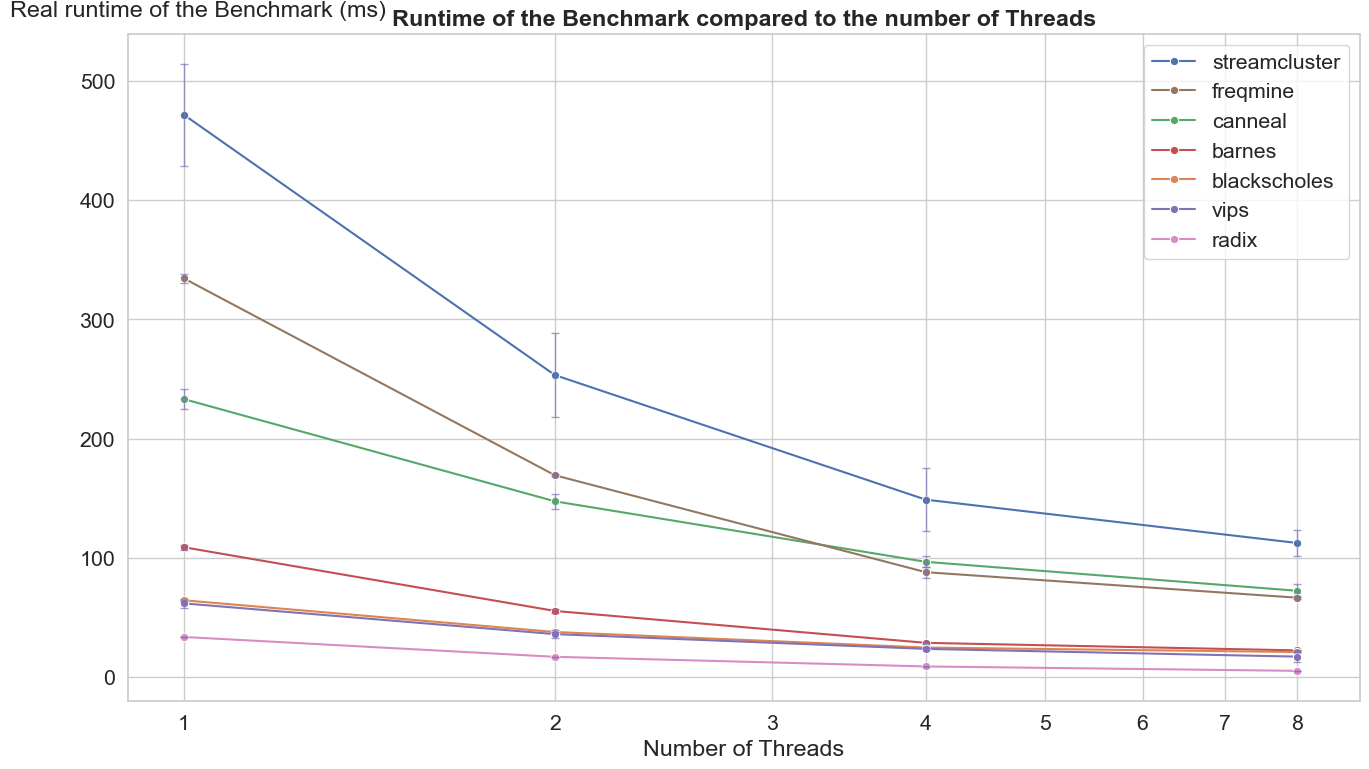

In [193]:
sns.set_theme(style="whitegrid",font_scale=1.4)

fig, ax = plt.subplots(figsize=(14, 8))

plot_with_errorbars(ax, part2b_dataframe_avg, "No Interference")

# Logarithmic x-axis
ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(1, 9, 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t)}" for t in ticks])

# Limits
ax.set_xlim(0, 9)
# ax.set_ylim(0, 6)

# Labels and title
ax.set_xlabel("Number of Threads")
ax.set_ylabel(
    "Real runtime of the Benchmark (ms)",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)
ax.set_title("Runtime of the Benchmark compared to the number of Threads", fontweight="bold")

# Grid
ax.grid(True, which="major", axis="both")

order_legend = [
    "streamcluster",
    "freqmine",
    "canneal",
    "barnes",
    "blackscholes",
    "vips",
    "radix"
]

handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[labels.index(label)] for label in order_legend]

# Legend
ax.legend(ordered_handles, order_legend)

plt.tight_layout()
plt.show()



In [199]:
palette = {
    "streamcluster": "#4C72B0",
    "blackscholes": "#DD8452",
    "canneal": "#55A868",
    "barnes": "#C44E52",
    "vips": "#8172B3",
    "freqmine": "#937860",
    "radix": "#DA8BC3"
}

markers = {
    "streamcluster": "o",
    "freqmine": "s",
    "canneal": "D",
    "barnes": "^",
    "blackscholes": "v",
    "vips": "P",
    "radix": "X"
}

def plot_with_errorbars(ax, data, label):
    # Draw line
    line = sns.lineplot(
        data=data,
        x="threads",
        y="speedup",
        hue='parsec_benchmark',
        style="parsec_benchmark",
        palette=palette, #sns.color_palette("colorblind"),
        markers=markers,
        linewidth=1.5,
        markersize=8,
        ax=ax
    )

    # Draw matching error bars
    for benchmark, group in data.groupby("parsec_benchmark"):

        ax.errorbar(
            group["threads"],
            group["speedup"],
            yerr=group["std_speedup"],
            fmt="none",
            ecolor=palette[benchmark],  # ← exact matching color
            capsize=5,
            elinewidth=1,
            alpha=0.7
        )

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_20663/201518837.py:67: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 9)
/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_20663/201518837.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


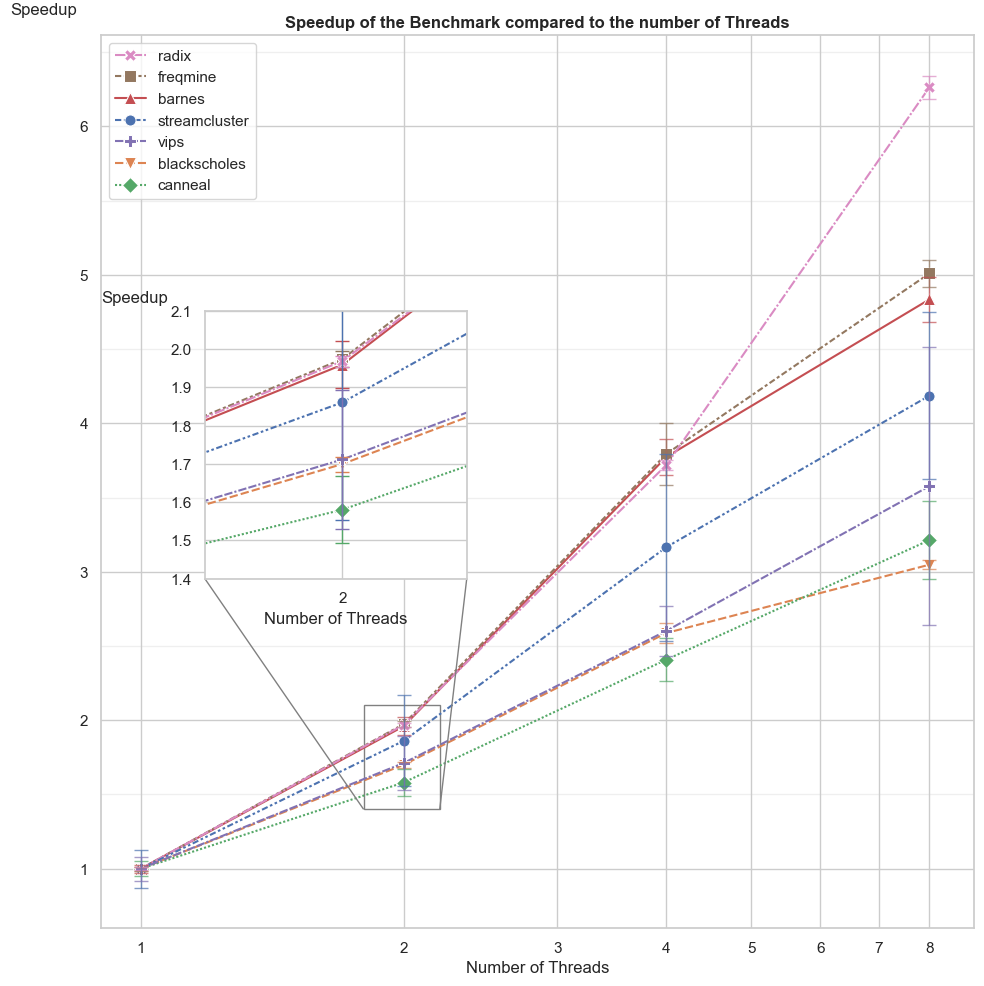

In [203]:
sns.set_theme(style="whitegrid",font_scale=1)

fig, ax = plt.subplots(figsize=(10, 10))

plot_with_errorbars(ax, part2b_dataframe_avg, "No Interference")

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(ax, width="30%", height="30%", loc="upper left", bbox_to_anchor=(0.11, -0.3, 1, 1), bbox_transform=ax.transAxes)

sns.lineplot(
    data=part2b_dataframe_avg[part2b_dataframe_avg["threads"].isin([1,2,4])],
    x="threads",
    y="speedup",
    hue="parsec_benchmark",
    style="parsec_benchmark",
    palette=palette,
    markers=markers,
    ax=axins,
    legend=False,
    markersize=8,
)

for benchmark, group in part2b_dataframe_avg.groupby("parsec_benchmark"):
    axins.errorbar(
        group["threads"],
        group["speedup"],
        yerr=group["std_speedup"],
        fmt="none",
        ecolor=palette[benchmark],  # ← exact matching color
        capsize=5,
        elinewidth=1,
        alpha=1
    )

axins.set_xscale("log")
axins.set_xlim(1.8, 2.2)
axins.set_ylim(1.4, 2.1)

axins.set_xticks([2])
axins.set_xticklabels(["2"])
axins.xaxis.set_minor_locator(ticker.NullLocator())

axins.set_xlabel("Number of Threads")
axins.set_ylabel(
    "Speedup",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)

# Logarithmic x-axis
ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(1, 9, 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t)}" for t in ticks])

ax.yaxis.set_minor_locator(
    ticker.MultipleLocator(0.5)
)

# Limits
ax.set_xlim(0, 9)
# ax.set_ylim(0, 6)

# Labels and title
ax.set_xlabel("Number of Threads")
ax.set_ylabel(
    "Speedup",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)
ax.set_title("Speedup of the Benchmark compared to the number of Threads", fontweight="bold")

mark_inset(
    ax,        # main plot
    axins,     # inset plot
    loc1=3,    # corner 1
    loc2=4,    # corner 2
    fc="none",
    ec="0.5"
)

# Grid
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="y", alpha=0.3)

order_legend = [
    "radix",
    "freqmine",
    "barnes",
    "streamcluster",
    "vips",
    "blackscholes",
    "canneal"
]

handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[labels.index(label)] for label in order_legend]

# Legend
ax.legend(ordered_handles, order_legend)

plt.tight_layout()
plt.show()



/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_20663/2662431957.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


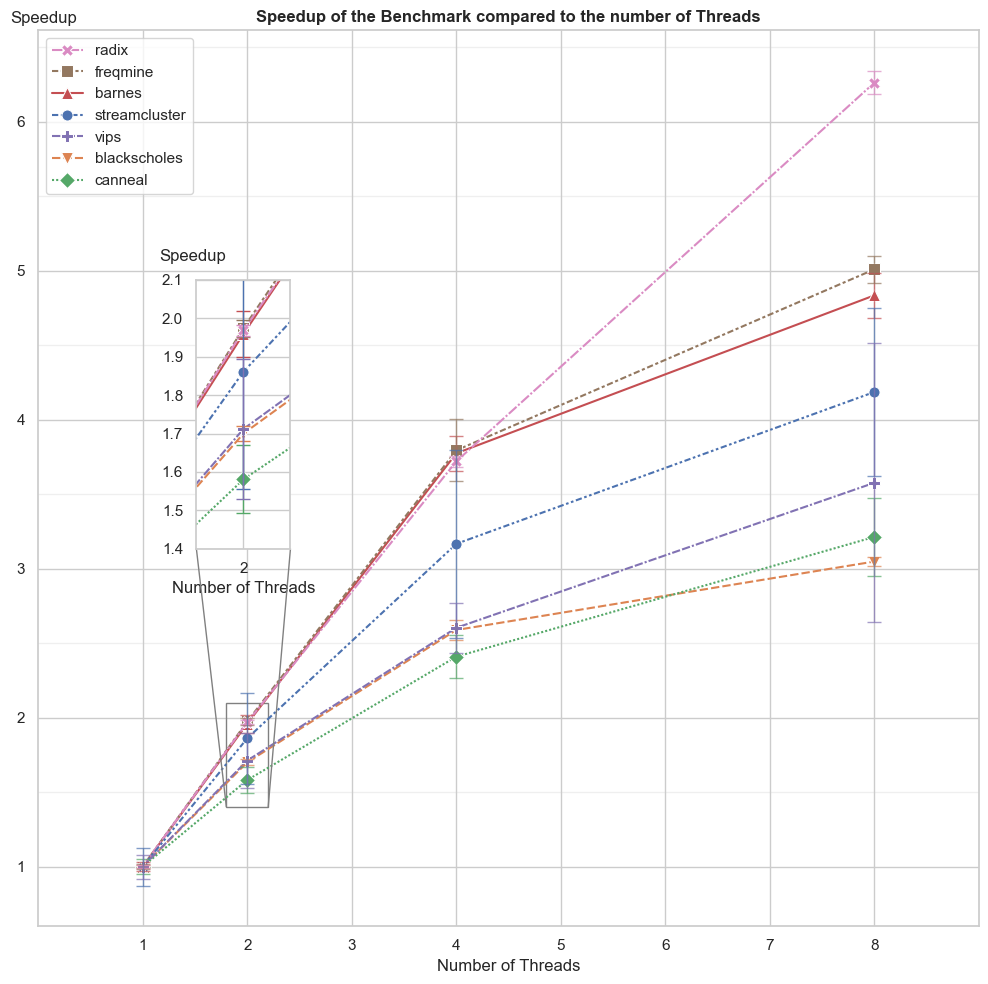

In [248]:
sns.set_theme(style="whitegrid",font_scale=1)

fig, ax = plt.subplots(figsize=(10, 10))

plot_with_errorbars(ax, part2b_dataframe_avg, "No Interference")

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(ax, width="10%", height="30%", loc="upper left", bbox_to_anchor=(0.16, -0.27, 1, 1), bbox_transform=ax.transAxes)

sns.lineplot(
    data=part2b_dataframe_avg,
    x="threads",
    y="speedup",
    hue="parsec_benchmark",
    style="parsec_benchmark",
    palette=palette,
    markers=markers,
    ax=axins,
    legend=False,
    markersize=8,
)

for benchmark, group in part2b_dataframe_avg.groupby("parsec_benchmark"):
    axins.errorbar(
        group["threads"],
        group["speedup"],
        yerr=group["std_speedup"],
        fmt="none",
        ecolor=palette[benchmark],  # ← exact matching color
        capsize=5,
        elinewidth=1,
        alpha=1
    )

# axins.set_xscale("log")
axins.set_xlim(1.8, 2.2)
axins.set_ylim(1.4, 2.1)

axins.set_xticks([2])
axins.set_xticklabels(["2"])
axins.xaxis.set_minor_locator(ticker.NullLocator())

axins.set_xlabel("Number of Threads")
axins.set_ylabel(
    "Speedup",
    rotation=0,
    ha="left",
    va="bottom",
    # labelpad=50,
    # y=1.02
)
axins.yaxis.set_label_coords(-0.4, 1.06)

# Logarithmic x-axis
# ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(1, 9, 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t)}" for t in ticks])

ax.yaxis.set_minor_locator(
    ticker.MultipleLocator(0.5)
)

# Limits
ax.set_xlim(0, 9)
# ax.set_ylim(0, 6)

# Labels and title
ax.set_xlabel("Number of Threads")
ax.set_ylabel(
    "Speedup",
    rotation=0,
    ha="left",
    va="bottom",
    # labelpad=50,
    # x=0.05,
    # y=1.01
)
ax.yaxis.set_label_coords(-0.03, 1.005)
ax.set_title("Speedup of the Benchmark compared to the number of Threads", fontweight="bold")

mark_inset(
    ax,        # main plot
    axins,     # inset plot
    loc1=3,    # corner 1
    loc2=4,    # corner 2
    fc="none",
    ec="0.5"
)

# Grid
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="y", alpha=0.3)

order_legend = [
    "radix",
    "freqmine",
    "barnes",
    "streamcluster",
    "vips",
    "blackscholes",
    "canneal"
]

handles, labels = ax.get_legend_handles_labels()
ordered_handles = [handles[labels.index(label)] for label in order_legend]

# Legend
ax.legend(ordered_handles, order_legend)

plt.tight_layout()
plt.show()

